In [1]:
import pandas as pd
import numpy as np

In [205]:
'''df0 = pd.read_csv('C:/Users/arj26323/Documents/Data/Restoration_trends/rest_trends.csv') ##Individual pixels
df0 = pd.read_csv('C:/Users/arj26323/Documents/Data/Restoration_trends/restoration_window_trends.csv') ##2x2 window
df0 = pd.read_csv('C:/Users/arj26323/Documents/Data/Restoration_trends/restoration_window_trends_3.csv') ##3x3 window
df0 = pd.read_csv('C:/Users/arj26323/Documents/Data/Restoration_trends/restoration_window_trends_4.csv') ##4x4 window
df0 = pd.read_csv('C:/Users/arj26323/Documents/Data/Restoration_trends/restoration_window_trends_5.csv') ##5x5 window'''

##UPDATED LS LOCATIONS:
# df0 = pd.read_csv('C:/Users/arj26323/Documents/Data/Restoration_trends/fixed_restoration_window_trends_1.csv') ##1x1

df0 = pd.read_csv('C:/Users/arj26323/Documents/Data/Restoration_trends/fixed_restoration_window_trends_3.csv') ##3x3 window

# df0 = pd.read_csv('C:/Users/arj26323/Documents/Data/Restoration_trends/fixed_restoration_window_trends_5.csv') ##5x5 window


df = df0.iloc[:, [3,4,5] + list(range(6,47))].dropna()

df

,Site name,Installation_year,type,geometry,biomass_1984,biomass_1985,biomass_1986,biomass_1987,biomass_1988,biomass_1989,...,biomass_2014,biomass_2015,biomass_2016,biomass_2017,biomass_2018,biomass_2019,biomass_2020,biomass_2021,biomass_2022,biomass_2023
0,Plantation Creek Site,2010,Oyster Reef,POINT (-81.477183 31.122967),415.569183,596.696716,424.160248,444.760101,454.666901,633.744324,...,468.044190,664.676269,467.191315,615.905273,478.254791,434.525177,714.136902,823.788635,479.731964,464.357910
1,Florida Passage Site,2012,Oyster Reef,POINT (-81.15333333 31.83865),546.787598,628.008118,713.233459,566.339539,714.556763,735.787537,...,392.914490,673.458801,477.707764,490.022613,480.411011,418.332519,560.940308,493.276245,459.225952,502.592590
2,Oatland Site,2014,Oyster Reef,POINT (-81.01923333 32.04801667),454.848907,431.684174,551.176636,462.359711,528.941162,523.316772,...,409.996338,560.010925,399.928101,434.612732,431.465637,378.262756,505.979706,516.557861,391.161011,401.994263
4,Estuaries Area of the Altamaha River,2009,Oyster Reef,POINT (-81.32228333 31.32615),432.954224,432.954224,346.108185,367.529571,435.826538,432.954224,...,1785.122437,1951.631470,1691.542358,1945.601929,1816.893677,1365.065308,1973.961060,1929.251587,1754.852905,1458.545532
5,Jekyll Island Boat Ramp Site,2009,Oyster Reef,POINT (-81.42301667 31.04165),426.000030,584.057495,406.831421,387.468353,468.236969,562.722290,...,403.886597,589.351074,412.766602,562.577576,411.958008,411.658356,465.735260,575.580261,408.291718,419.075836
7,Oyster Creek Site B,2013,Oyster Reef,POINT (-80.91488333 32.00441667),239.060226,372.658814,358.286591,291.562958,369.751556,366.183044,...,251.925461,379.952362,205.888474,232.572906,215.731125,246.284225,249.831177,214.575150,207.701630,215.857468
9,Jointer Creek Oyster Reef A,2012,Oyster Reef,POINT (-81.50021667 31.0808),280.419067,399.076416,300.492676,347.091125,369.082184,375.255920,...,246.608215,368.636231,251.039337,361.807617,229.932373,265.036041,363.710510,365.909576,254.114487,320.252197
10,Jointer Creek Oyster Reef B,2012,Oyster Reef,POINT (-81.49396667 31.0796),289.923523,397.946197,302.668671,360.008637,337.579590,381.647827,...,274.967621,381.692657,266.043488,378.523407,241.847824,267.323761,389.814179,370.218231,254.134232,271.862732
11,Jointer Creek Oyster Reef C,2012,Oyster Reef,POINT (-81.49078333 31.08058333),324.102203,431.120758,335.510895,355.180176,337.854858,380.114990,...,262.336914,375.519836,249.687531,361.999756,234.102936,269.492859,398.049225,368.151306,257.852875,271.058777
12,Jointer Creek Oyster Reef D,2012,Oyster Reef,POINT (-81.47005 31.0704),389.009094,544.705017,405.797211,418.006592,403.280395,508.578888,...,369.914581,668.582764,369.886169,505.491394,675.972778,384.359161,470.159119,603.878601,355.689270,916.806274


In [206]:
import seaborn as sns
import matplotlib.pyplot as plt

##With LS site updates, you need this:
df['Site'] = df['Site name']
df['Install_year'] = df['Installation_year'] ##manually changed from 'year' in output

df = df.drop(columns=['Site name', 'Installation_year', 'geometry'])

# 1. Melt the DataFrame
# Assumes 'site' is the column that identifies your locations
df_long = pd.melt(
    df, 
    id_vars=['Site', 'Install_year', 'type'], 
    var_name='year', 
    value_name='biomass'
)

# 2. Clean the 'year' column
# Remove 'biomass_' prefix and convert to numeric
df_long['year'] = df_long['year'].str.replace('biomass_', '').astype(int)

In [207]:
df_long['Site'].unique()

array(['Plantation Creek Site', 'Florida Passage Site', 'Oatland Site',
       'Estuaries Area of the Altamaha River',
       'Jekyll Island Boat Ramp Site', 'Oyster Creek Site B',
       'Jointer Creek Oyster Reef A', 'Jointer Creek Oyster Reef B',
       'Jointer Creek Oyster Reef C', 'Jointer Creek Oyster Reef D',
       'Turtle A', 'Turtle B', 'Turtle C', 'Turtle D', 'Turtle E',
       'Bellville Boat Ramp Site', 'Ashantilly, Sapelo Island',
       'Long Tabby, Sapelo Island',
       "Mosquito Creek, Little St. Simon's Island",
       "Cannon's Point Preserve, St. Simon's Island",
       'Skidaway Island State Park, Skidaway Island',
       'Burton 4-H, Tybee Island',
       'Beach Road Bridge, Little St. Simons Island',
       'Little Cumberland Island', 'Fortson Pond, Jekyll Island',
       "DNR's Coastal Regional Headquarters, Brunswick", 'Jekyll TLP'],
      dtype=object)

In [208]:
'''##Adding installation year
df2 = pd.read_csv('C:/Users/arj26323/Documents/Data/GA_conservation/all_active_years_installations.csv')

df2['Install_year'] = df2['year']
df2['Site'] = df2['Site name']


df_insta = df2[['Site', 'Install_year']].copy()

# df_insta[df_insta['Site'] == "Mosquito Creek, Little St. Simon's Island"]
# df_insta'''

'##Adding installation year\ndf2 = pd.read_csv(\'C:/Users/arj26323/Documents/Data/GA_conservation/all_active_years_installations.csv\')\n\ndf2[\'Install_year\'] = df2[\'year\']\ndf2[\'Site\'] = df2[\'Site name\']\n\n\ndf_insta = df2[[\'Site\', \'Install_year\']].copy()\n\n# df_insta[df_insta[\'Site\'] == "Mosquito Creek, Little St. Simon\'s Island"]\n# df_insta'

In [209]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Remove leading/trailing whitespace
df_long['Site'] = df_long['Site'].str.strip()
'''df_insta['Site'] = df_insta['Site'].str.strip()
'''
# Normalize apostrophes: Replace curly/smart quotes with standard straight quotes
df_long['Site'] = df_long['Site'].str.replace("’", "'").str.replace("`", "'")
'''df_insta['Site'] = df_insta['Site'].str.replace("’", "'").str.replace("`", "'")
'''
'''df_long_install = pd.merge(df_long, df_insta, on = 'Site')

df_long_install = df_long_install[df_long_install['Site'] != "DNR's Coastal Regional Headquarters, Brunswick"] ##FLATS issues?'''

'''g = sns.FacetGrid(df_long_install, col="Site", col_wrap=4, height=3, sharey=True)
g.map(sns.scatterplot, "year", "biomass", marker='o', color = 'black')
# g.set_titles("{col_name}")
for site_name, ax in g.axes_dict.items():
    # Truncate the key string, not the axis object
    display_name = site_name if len(site_name) <= 30 else site_name[:30] + "..."
    
    # Set the title on the correct axis
    ax.set_title(display_name)
    
    # Get install year for this site
    install_year = (
        df_long_install.loc[df_long_install["Site"] == site_name, "Install_year"]
        .iloc[0]
    )

    # Add vertical dotted line
    ax.axvline(
        x=install_year,
        linestyle=":",
        color="red",
        linewidth=1.5
    )



g.set_axis_labels("", "AGB (g/$m^2$)")
g.set(ylim=(0, None))
plt.tight_layout()'''


# ##Save at high res
# import os
# output_dir = r'F:\Figures_PaperII'
# file_name = 'resorationsitetrends.tif'

# save_path = os.path.join(output_dir, file_name)

# # plt.savefig(save_path, bbox_inches='tight', dpi=1000)

# plt.show()

'g = sns.FacetGrid(df_long_install, col="Site", col_wrap=4, height=3, sharey=True)\ng.map(sns.scatterplot, "year", "biomass", marker=\'o\', color = \'black\')\n# g.set_titles("{col_name}")\nfor site_name, ax in g.axes_dict.items():\n    # Truncate the key string, not the axis object\n    display_name = site_name if len(site_name) <= 30 else site_name[:30] + "..."\n    \n    # Set the title on the correct axis\n    ax.set_title(display_name)\n    \n    # Get install year for this site\n    install_year = (\n        df_long_install.loc[df_long_install["Site"] == site_name, "Install_year"]\n        .iloc[0]\n    )\n\n    # Add vertical dotted line\n    ax.axvline(\n        x=install_year,\n        linestyle=":",\n        color="red",\n        linewidth=1.5\n    )\n\n\n\ng.set_axis_labels("", "AGB (g/$m^2$)")\ng.set(ylim=(0, None))\nplt.tight_layout()'

In [210]:
df_flats = pd.read_csv('C:/Users/arj26323/Documents/Data/GA_conservation/Landsat_40Year_TimeSeries.csv')

df_flats['Site'] = df_flats['Site name']
df_flats['Install_year'] = df_flats['year']

dfx = df_flats[['Site', 'Install_year', 'date', 'evi_mean', 'flats_mean']].copy()

dfx['Site'] = dfx['Site'].replace({"DNR's Costal Regional Headquarters, Brunswick": 
                                   "DNR's Coastal Regional Headquarters, Brunswick"})
dfx

,Site,Install_year,date,evi_mean,flats_mean
0,Plantation Creek Site,2010,1984-04,0.030452,0.389619
1,Florida Passage Site,2012,1984-04,0.012869,0.711791
2,Oatland Site,2014,1984-04,0.034820,0.271140
3,Skidaway River Site,2010,1984-04,0.068154,0.428756
4,Estuaries Area of the Altamaha River,2009,1984-04,-0.019164,0.999925
...,...,...,...,...,...
14317,"Beach Road Bridge, Little St. Simons Island",2017,2022-12,0.075881,0.008023
14318,Little Cumberland Island,2020,2022-12,0.046656,0.256583
14319,"Fortson Pond, Jekyll Island",2021,2022-12,0.145541,0.000780
14320,"DNR's Coastal Regional Headquarters, Brunswick",2023,2022-12,0.042469,0.143818


In [211]:
# Convert 'date' to datetime and extract the year
dfx['date'] = pd.to_datetime(dfx['date'], format='%Y-%m')
dfx['year'] = dfx['date'].dt.year

# Calculate annual mean for flats
dfx_annual = dfx.groupby(['Site', 'year'])['flats_mean'].mean().reset_index()

# df_long_install['date_dt'] = pd.to_datetime(df_long_install['year'].astype(str), format='%Y')

# Merge into your main plotting dataframe
'''df_merged = df_long_install.merge(dfx_annual, on=['Site', 'year'], how='left')
'''
df_merged = df_long.merge(dfx_annual, on=['Site', 'year'], how='left')

df_merged = df_merged[df_merged['type'] == 'Oyster Reef'] ##Testing statistics just using the more open ORs

# len(df_long_install['Site'].unique())

C:\Users\arj26323\AppData\Local\Temp\ipykernel_15588\846991882.py:28: MatplotlibDeprecationWarning: 
The is_last_col function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use ax.get_subplotspec().is_last_col() instead.
  if ax.is_last_col():


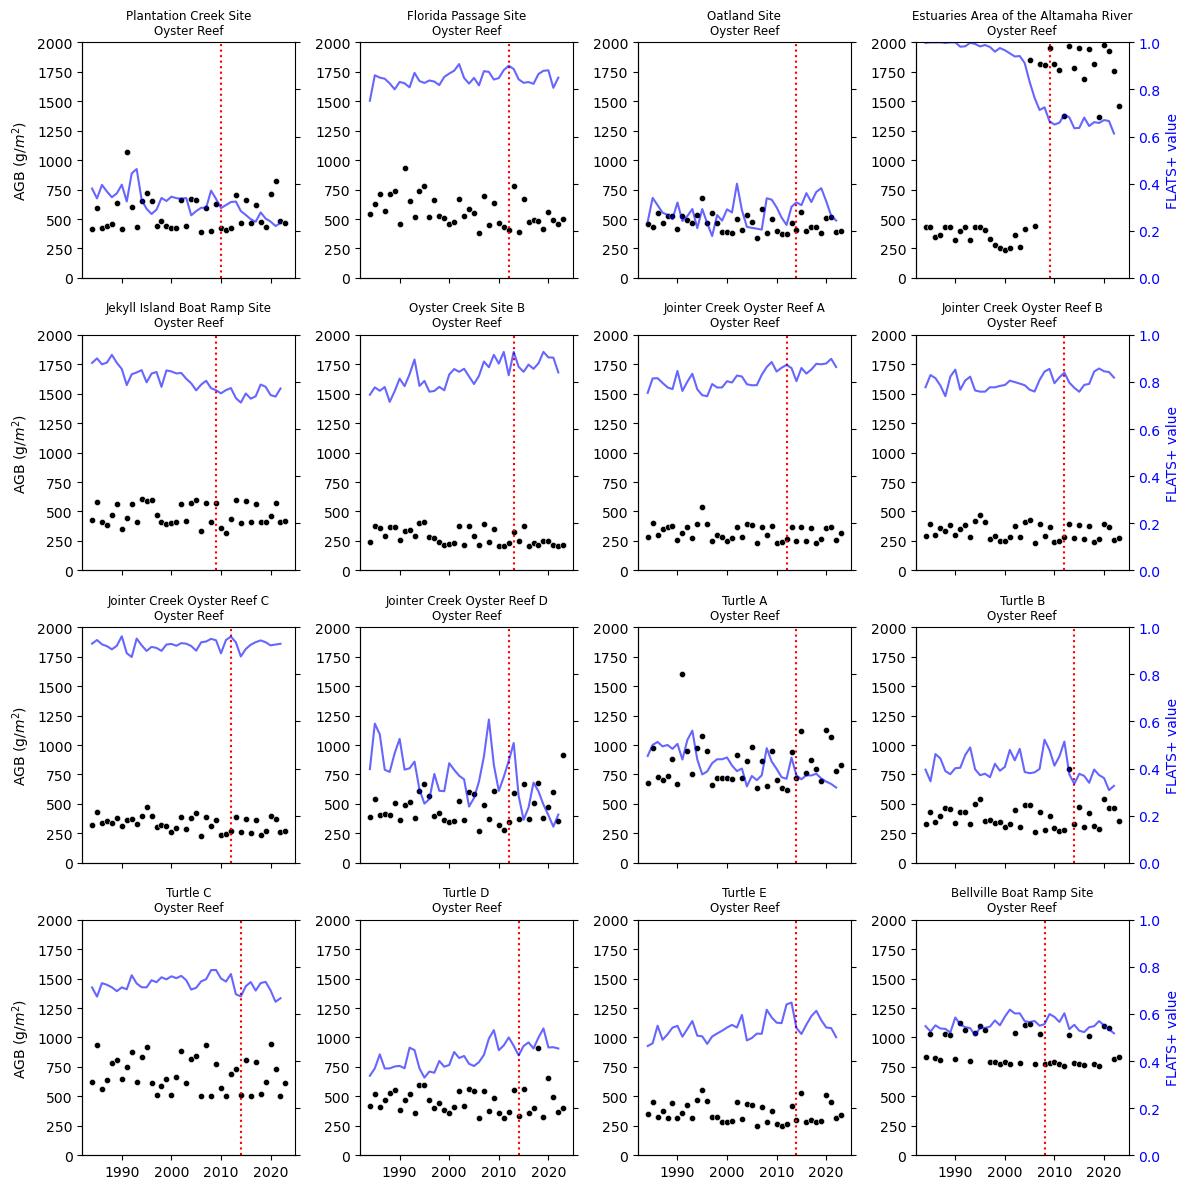

In [212]:
# Create the FacetGrid
g = sns.FacetGrid(df_merged, col="Site", col_wrap=4, height=3, sharey=True)

site_type_map = df_merged.groupby('Site')['type'].first().to_dict()

# Map the scatterplot
g.map(sns.scatterplot, "year", "biomass", marker='o', color='black', s=20)

for site_name, ax in g.axes_dict.items():
    
    # Get the type for this site
    site_type = site_type_map.get(site_name, "Unknown")
    
    # Update the title to include both Site and Type
    ax.set_title(f"{site_name}\n{site_type}", size=8.5)
    
    # 1. Create the second axis
    ax2 = ax.twinx()
    
    # 2. Filter data for this specific site
    site_data = df_merged[df_merged["Site"] == site_name]
    
    # 3. Plot the flats_mean on the twin axis
    ax2.plot(site_data["year"], site_data["flats_mean"], color='blue', alpha=0.6, label='Flats')
    
    # 4. Conditionally set labels to avoid repetition
    # Only show the ylabel for the right-most columns
    if ax.is_last_col():
        ax2.set_ylabel("FLATS+ value", color='blue')
    else:
        ax2.set_ylabel("")
        # Hide tick labels for non-right columns if preferred
        ax2.tick_params(axis='y', labelright=False)
        
    ax2.tick_params(axis='y', labelcolor='blue')
    ax2.set_ylim(0, 1)
    
    # Add your existing vertical line
    install_year = site_data["Install_year"].iloc[0]
    ax.axvline(x=install_year, linestyle=":", color="red", linewidth=1.5)

g.set_axis_labels("", "AGB (g/$m^2$)")
g.set(ylim=(0, 2000))
'''g.set_titles("{col_name}", size = 8.5)
'''    
plt.tight_layout()


##Save at high res
import os
output_dir = r'F:\Figures_PaperII'
file_name = 'FIXED_resorationsitetrends_5.tif'

save_path = os.path.join(output_dir, file_name)

# plt.savefig(save_path, bbox_inches='tight', dpi=1000)
plt.show()

In [214]:
import statsmodels.formula.api as smf

# Create a 'years_since_install' column
df_merged['years_since_install'] = df_merged['year'] - df_merged['Install_year']
df_merged['time_since_intervention'] = (df_merged['year'] - df_merged['Install_year']).clip(lower=0)
df_merged['installation_year'] = df_merged['Install_year']

# Clean the data before modeling
df_clean = df_merged.dropna(subset=['biomass', 'flats_mean', 'years_since_install', 'Site']).copy()
df_clean = df_clean.reset_index(drop=True)

'''# Build the model
model = smf.mixedlm("biomass ~ flats_mean * years_since_install", 
                    df_clean, 
                    groups=df_clean["Site"])
result = model.fit()
print(result.summary())'''

'# Build the model\nmodel = smf.mixedlm("biomass ~ flats_mean * years_since_install", \n                    df_clean, \n                    groups=df_clean["Site"])\nresult = model.fit()\nprint(result.summary())'

In [217]:
import statsmodels.formula.api as smf

df = df_clean.copy() #be careful of df overlap

df =df[df['Site'] != 'Estuaries Area of the Altamaha River'] ##Just in case - improves residuals vs. fitted as well

df['PostInstall'] = (
    df['year'] >= df['installation_year']
).astype(int)

df['YearSinceInstall'] = np.maximum(
    0,
    df['year'] - df['installation_year']
)

model = smf.mixedlm(
    "biomass ~ year + PostInstall + YearSinceInstall",
    data=df,
    groups=df["Site"]
)

# model = smf.mixedlm(
#     "flats_mean ~ year + PostInstall + YearSinceInstall",
#     data=df,
#     groups=df["Site"]
# )


result = model.fit()
print(result.summary())

              Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    biomass   
No. Observations:     585        Method:                REML      
No. Groups:           15         Scale:                 12500.9969
Min. group size:      39         Log-Likelihood:        -3612.0093
Max. group size:      39         Converged:             Yes       
Mean group size:      39.0                                        
------------------------------------------------------------------
                   Coef.   Std.Err.   z    P>|z|  [0.025   0.975] 
------------------------------------------------------------------
Intercept         4895.743 1319.910  3.709 0.000 2308.767 7482.719
year                -2.201    0.660 -3.334 0.001   -3.495   -0.907
PostInstall          1.547   19.394  0.080 0.936  -36.465   39.560
YearSinceInstall     5.410    2.713  1.994 0.046    0.092   10.728
Group Var        34021.121  117.514                               



'# 1. Create the indicator variables\n# \'post_intervention\': 0 before install_year, 1 after\ndf_merged[\'post_intervention\'] = (df_merged[\'year\'] >= df_merged[\'Install_year\']).astype(int)\n\n# 2. Create a \'time_since_intervention\' variable\ndf_merged[\'time_since_intervention\'] = (df_merged[\'year\'] - df_merged[\'Install_year\']).clip(lower=0)\n\n# 3. The Model\nmodel = smf.ols("biomass ~ year + post_intervention + time_since_intervention + flats_mean + Site", data=df_merged).fit()\n\n# print(model.summary())\n\nimport statsmodels.formula.api as smf\n\n# Model: \n# biomass ~ time + post_intervention + time_since_intervention \n# + (1 + time_since_intervention | Site)\n# This model says: "Every site has a different starting point (intercept) \n# and a different growth rate (slope), but is there a common effect \n# for the \'post_intervention\' jump?"\n\nmodel = smf.mixedlm("biomass ~ year + post_intervention + time_since_intervention", \n                    data=df_clean, \n 

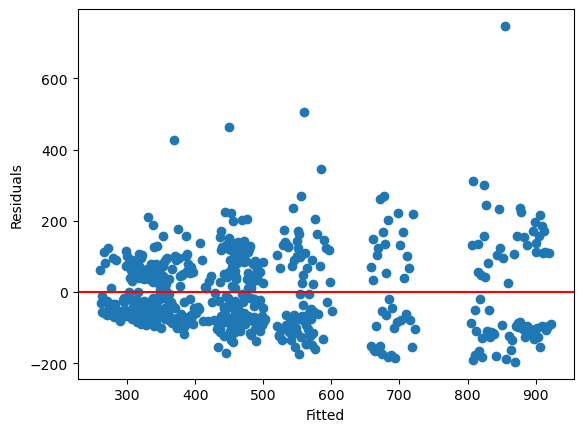

In [218]:
import matplotlib.pyplot as plt

fitted = result.fittedvalues
resid = result.resid

plt.scatter(fitted, resid)
plt.axhline(0, color='red')
plt.xlabel("Fitted")
plt.ylabel("Residuals")
plt.show()

# plt.hist(result.fittedvalues, bins=30)
# plt.xlabel("Fitted values")
# plt.show()

# df['resid'] = result.resid

# sns.scatterplot(
#     data=df,
#     x=result.fittedvalues,
#     y='resid',
#     hue='Site'
# )
# plt.axhline(0, color='red')

In [22]:
'''import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Biomass data (Assuming 'year' is just an integer like 1984)
df_long_install['date_dt'] = pd.to_datetime(df_long_install['year'], format='%Y')

# 2. Prepare Flats data
dfx['date_dt'] = pd.to_datetime(dfx['date'], format='%Y-%m')

# 3. Create the Grid
g = sns.FacetGrid(df_long_install, col="Site", col_wrap=4, height=3, sharey=True)

# Map the biomass as points
g.map(sns.scatterplot, "date_dt", "biomass", marker='o', color='black', s=20)

for site_name, ax in g.axes_dict.items():
    # Create twin axis
    ax2 = ax.twinx()
    
    # Filter both datasets for the current site
    bio_site = df_long_install[df_long_install["Site"] == site_name]
    flats_site = dfx[dfx["Site"] == site_name]
    
    # Plot Flats as a continuous line
    ax2.plot(flats_site["date_dt"], flats_site["flats_mean"], color='blue', alpha=0.5, linewidth=1)
    ax2.set_ylim(0, 1)
    ax2.set_ylabel("FLATS+ value", color='blue')


    
    # Add vertical line for installation year
    install_year = bio_site["Install_year"].iloc[0]
    ax.axvline(x=pd.to_datetime(str(install_year)), linestyle=":", color="red", linewidth=1.5)

# Final cleanup
g.set_axis_labels("", "AGB (g/$m^2$)")
plt.tight_layout()'''

'import pandas as pd\nimport matplotlib.pyplot as plt\nimport seaborn as sns\n\n# 1. Prepare Biomass data (Assuming \'year\' is just an integer like 1984)\ndf_long_install[\'date_dt\'] = pd.to_datetime(df_long_install[\'year\'], format=\'%Y\')\n\n# 2. Prepare Flats data\ndfx[\'date_dt\'] = pd.to_datetime(dfx[\'date\'], format=\'%Y-%m\')\n\n# 3. Create the Grid\ng = sns.FacetGrid(df_long_install, col="Site", col_wrap=4, height=3, sharey=True)\n\n# Map the biomass as points\ng.map(sns.scatterplot, "date_dt", "biomass", marker=\'o\', color=\'black\', s=20)\n\nfor site_name, ax in g.axes_dict.items():\n    # Create twin axis\n    ax2 = ax.twinx()\n    \n    # Filter both datasets for the current site\n    bio_site = df_long_install[df_long_install["Site"] == site_name]\n    flats_site = dfx[dfx["Site"] == site_name]\n    \n    # Plot Flats as a continuous line\n    ax2.plot(flats_site["date_dt"], flats_site["flats_mean"], color=\'blue\', alpha=0.5, linewidth=1)\n    ax2.set_ylim(0, 1)\n   

In [18]:
# df_short = df_long[df_long['Site'] == 'Estuaries Area of the Altamaha River']

# # 3. Plotting
# plt.figure(figsize=(12, 6))
# sns.scatterplot(data=df_short, x='year', y='biomass', marker='o', color = 'black')

# plt.xlabel('Year')
# plt.ylabel('AGB (g/$m^2$)')
# plt.ylim(0, None)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()


In [65]:
##Major and Savannah and Jekyll-ish hotspot trends

# dfx = pd.read_csv('C:/Users/arj26323/Documents/Data/Restoration_trends/major_hotspots_trends.csv') ##only big hotspots 
dfx = pd.read_csv('C:/Users/arj26323/Documents/Data/Restoration_trends/savan_hotspots_trends.csv') ##only savannah hotspots 

dfx

dfy = dfx.groupby(['year'])[['mean', 'std']].mean().reset_index()
dfy

dfy = pd.read_csv('C:/Users/arj26323/Documents/Data/Restoration_trends/jekyllish_hotspots_trends.csv')
dfy


dfz = pd.read_csv('C:/Users/arj26323/Documents/Data/Restoration_trends/sapelo_hotspots_trends.csv')
dfz


df10 = pd.read_csv('C:/Users/arj26323/Documents/Data/Restoration_trends/all_10hectare_hotspots_trends.csv')
df10



'''
Savannah polygon coordinates:

0: 32.0823; -81.0134
1: 32.0669; -81.0108
2: 32.0645; -80.9617
3: 32.0604; -80.9981
4: 32.0575; -80.9939
5: 32.0588; -80.9545
6: 32.0488; -80.9447
7: 32.0411; -81.0354


Largest polygon coordinates:

0:
1:
2:
3:
4:
5:
6:
7:
8:
9:
10:

Jekyllish polygon coordinates:

0: 31.0000; -81.4606


Sapelo polygon coordinates:
0: 31.4935; -81.2623



'''

'\nSavannah polygon coordinates:\n\n0: 32.0823; -81.0134\n1: 32.0669; -81.0108\n2: 32.0645; -80.9617\n3: 32.0604; -80.9981\n4: 32.0575; -80.9939\n5: 32.0588; -80.9545\n6: 32.0488; -80.9447\n7: 32.0411; -81.0354\n\n\nLargest polygon coordinates:\n\n0:\n1:\n2:\n3:\n4:\n5:\n6:\n7:\n8:\n9:\n10:\n\nJekyllish polygon coordinates:\n\n0: 31.0000; -81.4606\n\n\nSapelo polygon coordinates:\n0: 31.4935; -81.2623\n\n\n\n'

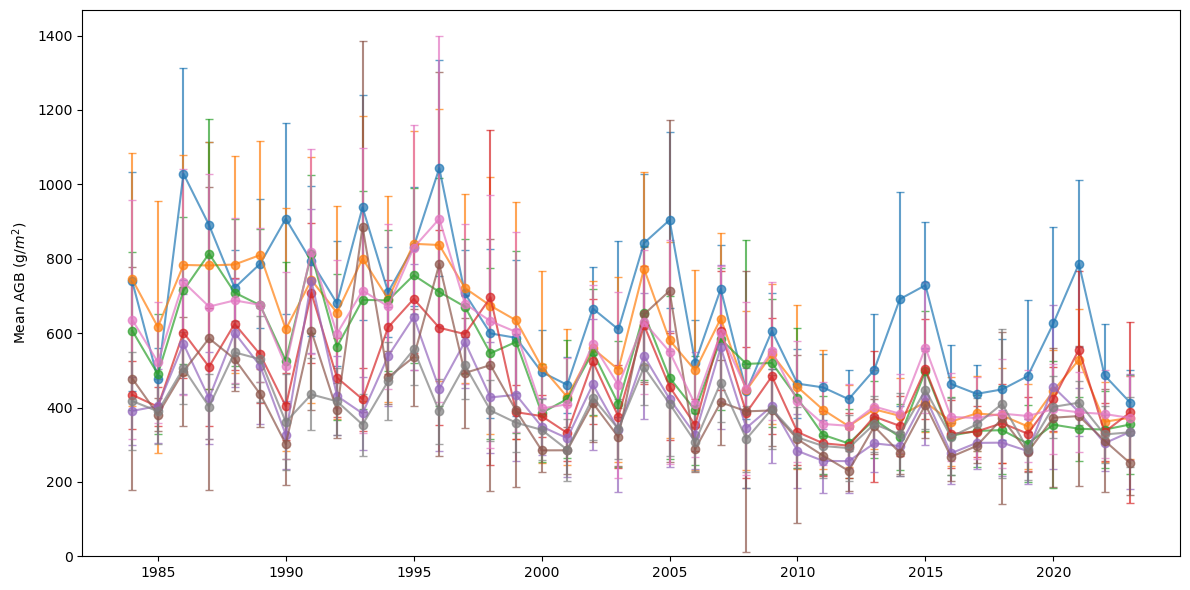

In [66]:
import matplotlib.pyplot as plt

# dfx = df10

# Filter for one polygon if you want to test, or loop through unique IDs
unique_polygons = dfx['polygon_id'].unique()

plt.figure(figsize=(12, 6))

for pid in unique_polygons:
    subset = dfx[dfx['polygon_id'] == pid]
    
    # Plot mean with std as error bar
    plt.errorbar(
        subset['year'].astype(int), 
        subset['mean'], 
        yerr=subset['std'], 
        label=f'Polygon {pid}',
        fmt='-o', 
        capsize=3,
        alpha=0.7
    )

plt.xlabel('')
plt.ylabel('Mean AGB (g/$m^2$)')
# plt.ylim(0, 1000)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0, None) # Keeping y-axis at 0
plt.tight_layout()
plt.show()

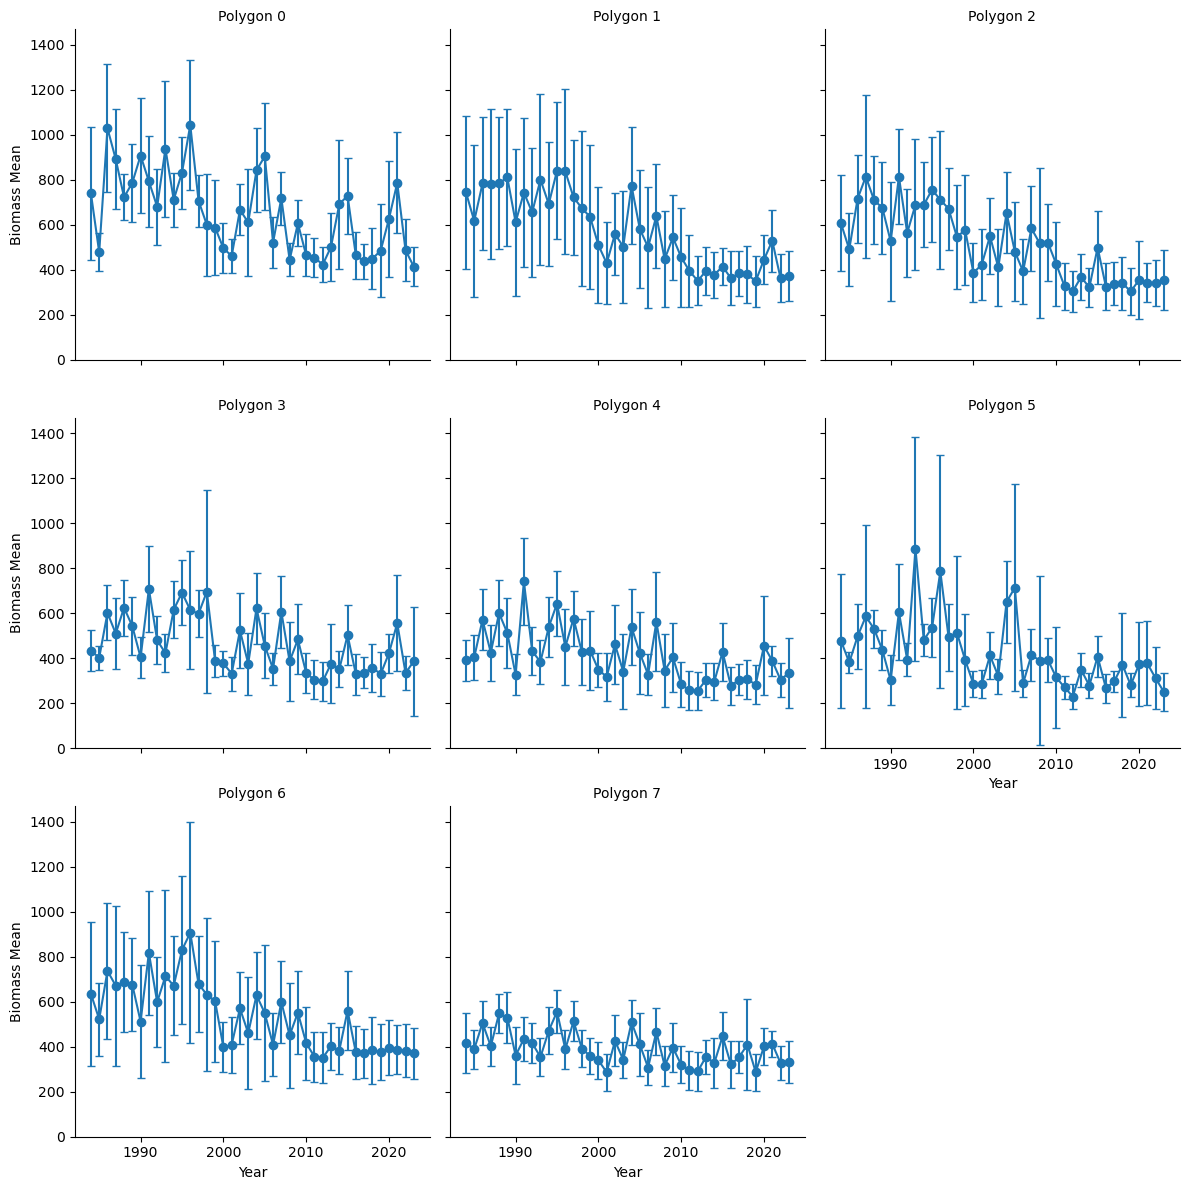

In [67]:
import seaborn as sns

g = sns.FacetGrid(dfx, col="polygon_id", col_wrap=3, height=4, sharey=True)
g.map(plt.errorbar, "year", "mean", "std", fmt="-o", capsize=3)
g.set_titles("Polygon {col_name}")
g.set_axis_labels("Year", "Biomass Mean")
g.set(ylim=(0, None))
plt.tight_layout()
plt.show()

In [219]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(12, 6))

    
# # Plot mean with std as error bar
# plt.errorbar(
#     subset['year'].astype(int), 
#     subset['mean'], 
# #     yerr=subset['std'], 
#     label=f'Polygon {pid}',
#     fmt='o', 
#     capsize=3,
#     alpha=0.7
# )

# plt.xlabel('')
# plt.ylim(0, 1500)
# plt.ylabel('Mean AGB (g/$m^2$)')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# # plt.grid(True, linestyle='--', alpha=0.6)
# plt.ylim(0, None) # Keeping y-axis at 0
# plt.tight_layout()
# plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


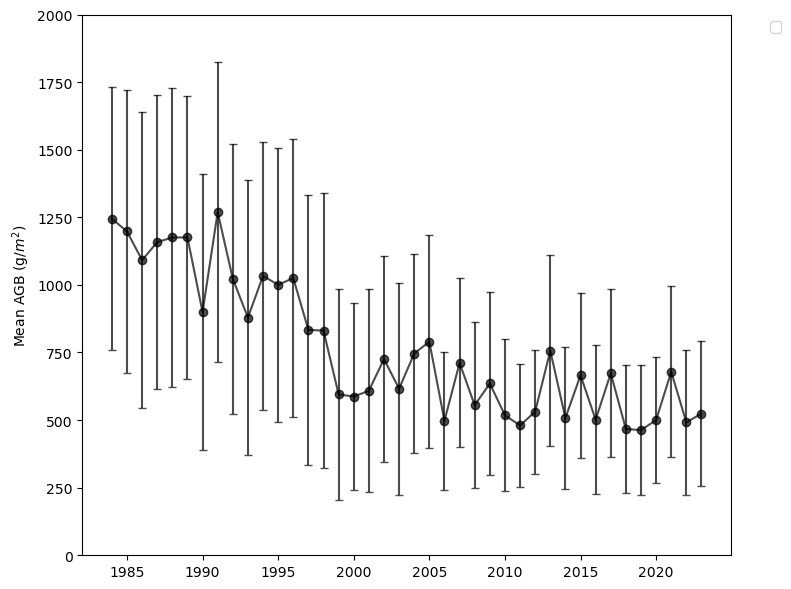

In [64]:
##Jekyll area 

# dfy = dfz

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Plot mean with std as error bar
plt.errorbar(
    dfy['year'].astype(int), 
    dfy['mean'], 
    yerr=dfy['std'], 
    fmt='-o',
    color = 'black',
    capsize=3,
    alpha=0.7
)

plt.xlabel('')
plt.ylim(0, 2000)
plt.ylabel('Mean AGB (g/$m^2$)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0, None) # Keeping y-axis at 0
plt.tight_layout()
plt.show()

In [213]:
'''# Create the FacetGrid as before
g = sns.FacetGrid(df_merged, col="Site", col_wrap=4, height=3, sharey=True)

# Map the scatterplot
g.map(sns.scatterplot, "year", "biomass", marker='o', color='black', s=20)

for site_name, ax in g.axes_dict.items():
    # 1. Create the second axis
    ax2 = ax.twinx()
    
    # 2. Filter data for this specific site
    site_data = df_merged[df_merged["Site"] == site_name]
    
    # 3. Plot the flats_mean on the twin axis
    ax2.plot(site_data["year"], site_data["flats_mean"], color='blue', alpha=0.6, label='Flats')
    
    
    ax2.set_ylabel("FLATS+ value", color='blue')
    ax2.tick_params(axis='y', labelcolor='blue')
    ax2.set_ylim(0, 1)
    
    # Add your existing vertical line
    install_year = site_data["Install_year"].iloc[0]
    ax.axvline(x=install_year, linestyle=":", color="red", linewidth=1.5)

g.set_axis_labels("", "AGB (g/$m^2$)")
g.set(ylim=(0, 2000))
g.set_titles("{col_name}")
    
plt.tight_layout()

##Save at high res
import os
output_dir = r'F:\Figures_PaperII'
file_name = 'resorationsitetrends_FLATS.tif'

save_path = os.path.join(output_dir, file_name)

# plt.savefig(save_path, bbox_inches='tight', dpi=1000)

plt.show()'''

'# Create the FacetGrid as before\ng = sns.FacetGrid(df_merged, col="Site", col_wrap=4, height=3, sharey=True)\n\n# Map the scatterplot\ng.map(sns.scatterplot, "year", "biomass", marker=\'o\', color=\'black\', s=20)\n\nfor site_name, ax in g.axes_dict.items():\n    # 1. Create the second axis\n    ax2 = ax.twinx()\n    \n    # 2. Filter data for this specific site\n    site_data = df_merged[df_merged["Site"] == site_name]\n    \n    # 3. Plot the flats_mean on the twin axis\n    ax2.plot(site_data["year"], site_data["flats_mean"], color=\'blue\', alpha=0.6, label=\'Flats\')\n    \n    \n    ax2.set_ylabel("FLATS+ value", color=\'blue\')\n    ax2.tick_params(axis=\'y\', labelcolor=\'blue\')\n    ax2.set_ylim(0, 1)\n    \n    # Add your existing vertical line\n    install_year = site_data["Install_year"].iloc[0]\n    ax.axvline(x=install_year, linestyle=":", color="red", linewidth=1.5)\n\ng.set_axis_labels("", "AGB (g/$m^2$)")\ng.set(ylim=(0, 2000))\ng.set_titles("{col_name}")\n    \nplt

In [161]:
#Fin